In [1]:
%load_ext autoreload
%autoreload 2
import sys
if ".." not in sys.path:
    sys.path.append("..")

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import yfinance as yf
import pandas as pd

from signature.learning.signature_transform import RollingSignatureTransform, EFMSignatureTransform
from signature.learning.hyperparameters_optimization import optimize_lam_cv, grid_search_cv
import signature.tensor_algebra as ta

my_green = "#5b6c64"
my_copper = "#B56246"
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=[my_green, my_copper, "#322B4D", "#28BC9C", "#71074E"])

## SPX / VIX data

In [2]:
load_from = pd.to_datetime('1990-01-01') # pd.to_datetime('1995-01-01')  # Need at least 4 years prior to the first training day
train_start_date = pd.to_datetime('2000-01-01')
test_start_date = pd.to_datetime('2020-01-01') # pd.to_datetime('2019-01-01')
test_end_date = pd.to_datetime('2022-05-15')

load_from = pd.to_datetime('1990-01-01')
test_end_date = pd.to_datetime("2026-01-01")

In [3]:
# import yfinance as yf
# import pandas as pd
#
# # Updated Ticker Map
# # Note: International Volatility tickers are unstable on Yahoo.
# # We keep ^VIX and ^AXVI as they typically remain accessible.
# tickers = {
#     "VIX": "^VIX",             # US Volatility
#     "SPX": "^GSPC",            # US Underlying
#     "AXVI": "^AXVI",           # Australia Volatility
#     "ASJO": "^AXJO",           # Australia Underlying
#     "STOXX50E": "^STOXX50E",   # Eurozone Underlying
#     "DAX": "^GDAXI",           # Germany Underlying
#     "N225": "^N225",           # Japan Underlying
#     "NKVI.OS": "^NKVI.OS"      # Japan Volatility
# }
#
# def download_financial_data(start_date=load_from, end_date=test_end_date):
#     print(f"Downloading data...")
#
#     # auto_adjust=True fixes the FutureWarning you received
#     # actions=False speeds up the download
#     data = yf.download(
#         list(tickers.values()),
#         start=start_date,
#         end=end_date,
#         auto_adjust=True,
#         actions=False
#     )
#
#     # We extract only the 'Close' prices
#     df = data['Close']
#
#     # Rename columns back to readable names
#     inv_map = {v: k for k, v in tickers.items()}
#     df = df.rename(columns=inv_map)
#
#     # Forward fill to handle different international market holidays
#     # df = df.ffill().dropna()
#
#     return df
#
# df = download_financial_data()
#
# # Show status of what was successfully retrieved
# print("\n--- Download Results ---")
# for name in tickers.keys():
#     status = "✅ Success" if name in df.columns else "❌ Failed/Unavailable"
#     print(f"{name}: {status}")
#
# print("\nLast 5 rows of available data:")
# print(df.tail())

In [4]:
vi_underlying_dict = {
     "VIX": "SPX",             # US
     "AXVI": "ASJO",           # Australia
     "V2TX": "STOXX50E",       # Eurozone
     "VDAX": "DAX",            # Germany
     "NKVI.OS": "N225",        # Japan
}

df = pd.read_csv("data/vol_indices.csv", index_col=0)
df.index = pd.to_datetime(df.index)

<Axes: xlabel='Date'>

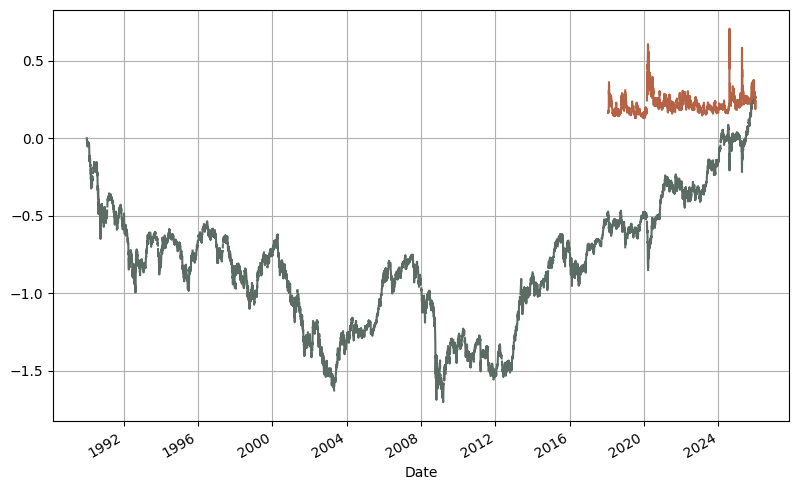

In [5]:
# Japan
np.log(df["N225"] / df["N225"].dropna().iloc[0]).plot()
(df["NKVI.OS"]).plot()

<Axes: xlabel='Date'>

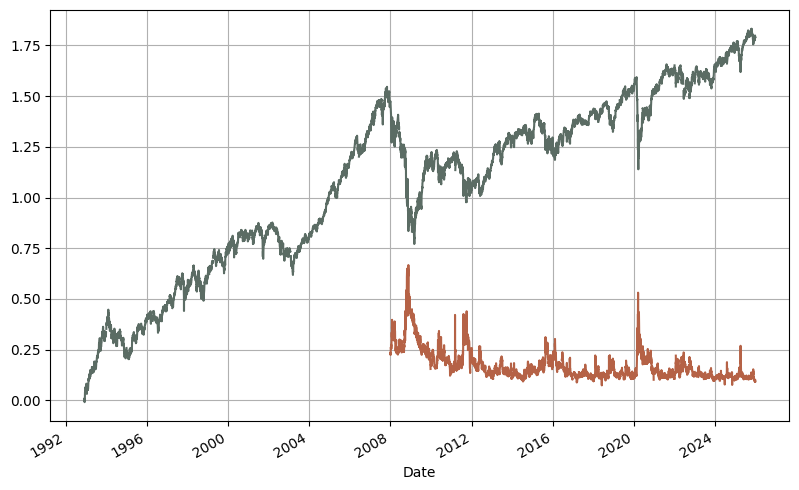

In [6]:
# Australia
(np.log(df["ASJO"] / df["ASJO"].dropna().iloc[0])).plot()
(df["AXVI"]).plot()

<Axes: xlabel='Date'>

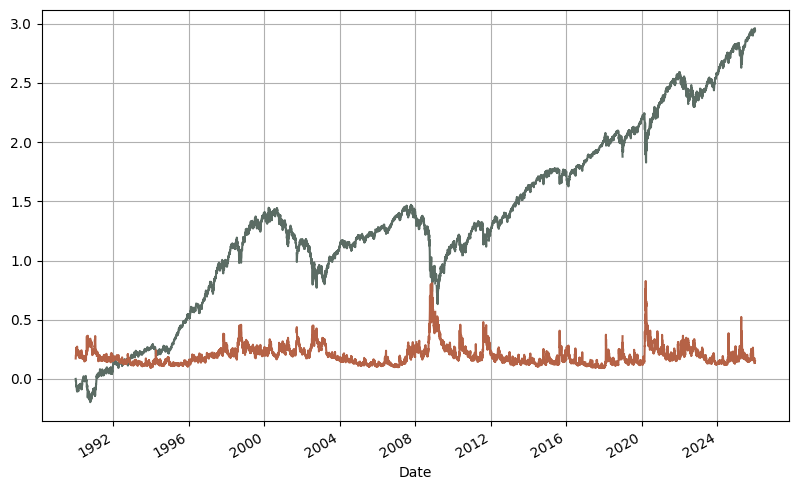

In [7]:
# US
np.log(df["SPX"] / df["SPX"].dropna().iloc[0]).plot()
(df["VIX"]).plot()

<Axes: xlabel='Date'>

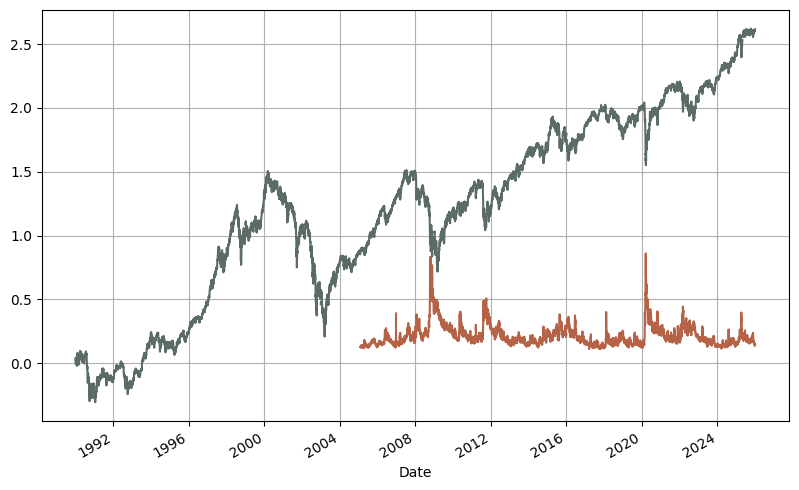

In [8]:
# Germany
np.log(df["DAX"] / df["DAX"].dropna().iloc[0]).plot()
(df["VDAX"]).plot()

<Axes: xlabel='Date'>

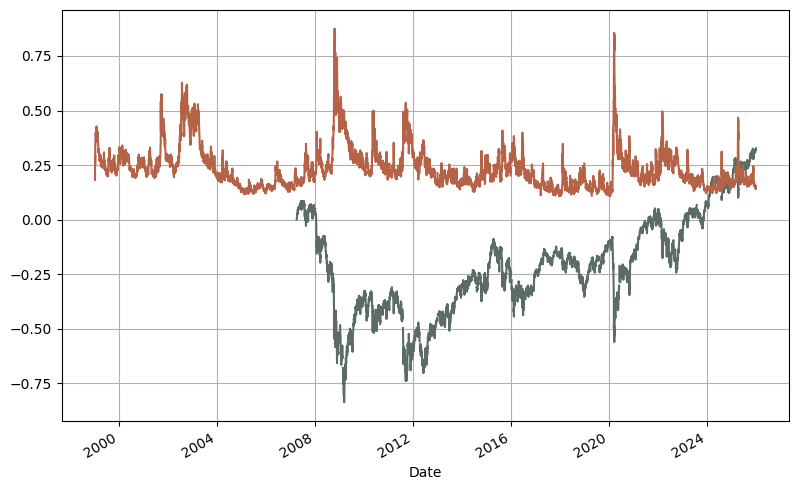

In [9]:
# Europe
np.log(df["STOXX50E"] / df["STOXX50E"].dropna().iloc[0]).plot()
(df["V2TX"]).plot()

In [10]:
volatility_index_ticker = "AXVI"  # "NKVI.OS"
stock_index_ticker = vi_underlying_dict[volatility_index_ticker]

df_country = pd.DataFrame(index=df.index, data=df[[stock_index_ticker, volatility_index_ticker]])
df_country = df_country.dropna(subset=[stock_index_ticker])

index = df_country.index
time_grid = np.array((index - index[0]).days / 365)
time_grid_train_test_threshold = np.array((test_start_date - index[0]).days / 365)
dates_grid = pd.to_datetime(pd.Series(index))

underlying = df_country[stock_index_ticker]
vol_index = df_country[volatility_index_ticker]

burn_in = np.where(index >= train_start_date)[0][0]
print("Burn-in:", burn_in)

Burn-in: 1800


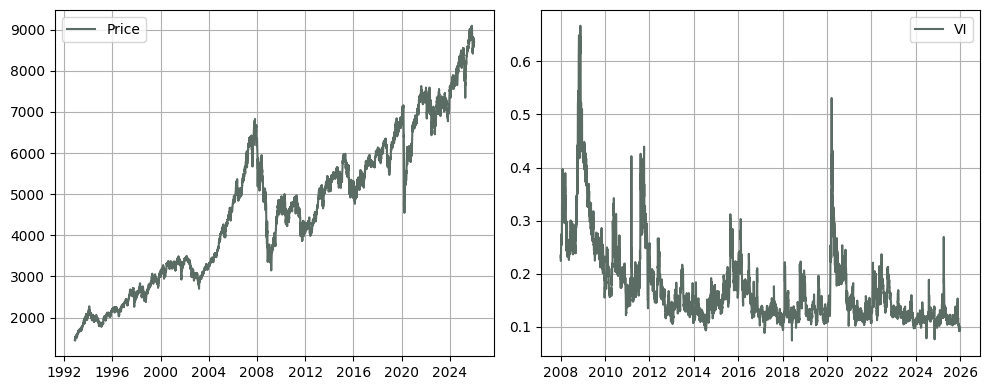

In [401]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(dates_grid, underlying, label="Price")
ax[0].legend()
# ax[1].plot(dates_grid, df_mkt.rv, label="RV")
ax[1].plot(dates_grid, vol_index, label="VI")
ax[1].legend()

## EFM-Signature model

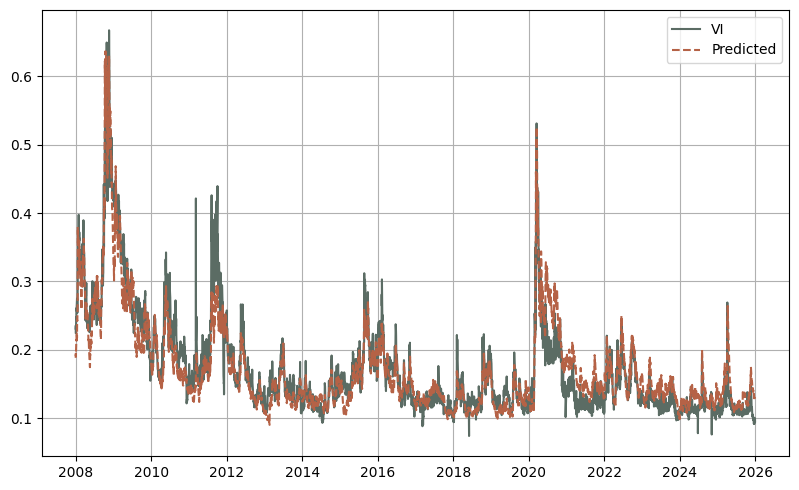

In [402]:
log_price = np.log(underlying)
vi_shifted = np.concatenate([vol_index[0:1], vol_index[:-1]])
integrated_vi = np.cumsum(vol_index)
integrated_shifted_vi = np.cumsum(vi_shifted)
quadratic_variation = np.concatenate([[0], np.cumsum(np.diff(log_price)**2)])

# path = np.vstack([
#     time_grid,
#     np.log(spx),
# ]).T
# trunc = 2
# lam = np.array([2, 8])
# kwargs = {"lead_lag": True, "lead_lag_idx": jnp.array([1]), "lam_idx": [0, 1, 1]}

path = np.vstack([
    time_grid,
    log_price / 10,
    quadratic_variation,
]).T
trunc = 2
lam = np.array([18, 12, 2])
kwargs = {}

# path = np.vstack([
#     time_grid,
#     np.log(spx),
#     np.concatenate([np.log(spx)[0:1], np.log(spx)[0:-1]]),
# ]).T
# trunc = 3
# lam = np.array([9, 1])
# kwargs = {"lam_idx": [0, 1, 1]}


dim = path.shape[1]
if "lead_lag_idx" in kwargs:
    dim += kwargs["lead_lag_idx"].size

X = np.hstack([time_grid[:, None], path])
y = np.array(vol_index[burn_in:])

transformer = EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **kwargs)
X = transformer.fit_transform(X, y)

y_nan_mask = ~np.isnan(y)
X = X[y_nan_mask]
y = y[y_nan_mask]
time_grid_masked = time_grid[burn_in:][y_nan_mask]
dates_grid_masked = dates_grid[burn_in:][y_nan_mask]

pipe = Pipeline([
    # ('sig', EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **kwargs)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

pipe.fit(X, y)

plt.plot(dates_grid_masked, y, label="VI")
plt.plot(dates_grid_masked, pipe.predict(X), "--", label="Predicted")
plt.legend()

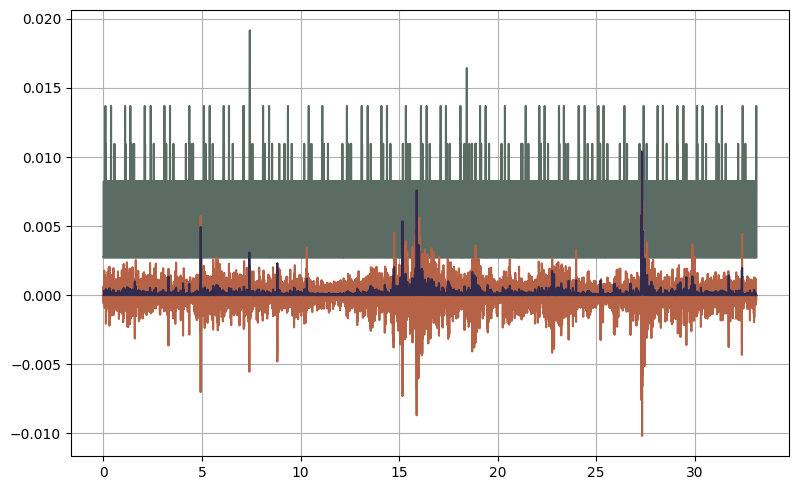

In [403]:
plt.plot(time_grid[1:], np.diff(path[:, 0], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 1], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 2], axis=0))

In [404]:
# 3. Create the Split
X_train, X_test = X[time_grid_masked < time_grid_train_test_threshold], X[time_grid_masked >= time_grid_train_test_threshold]  # X_test is full path to maintain EFM state
y_train, y_test = y[time_grid_masked < time_grid_train_test_threshold], y[time_grid_masked >= time_grid_train_test_threshold]

Train Metrics: RMSE = 0.0264, R2 = 0.8977
Test Metrics: RMSE = 0.0297, R2 = 0.6370


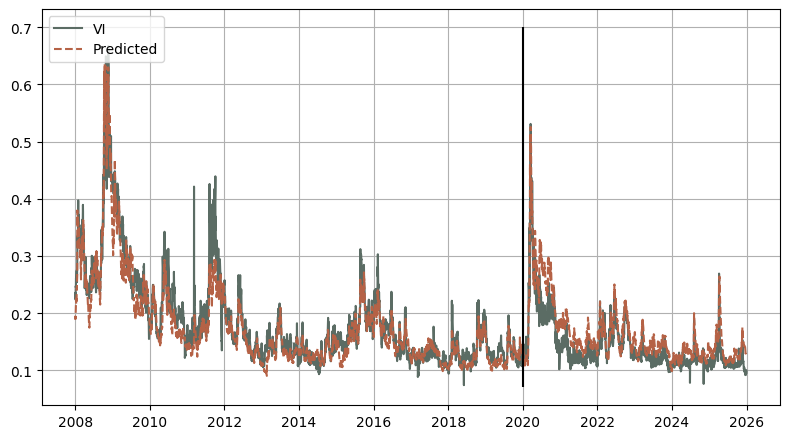

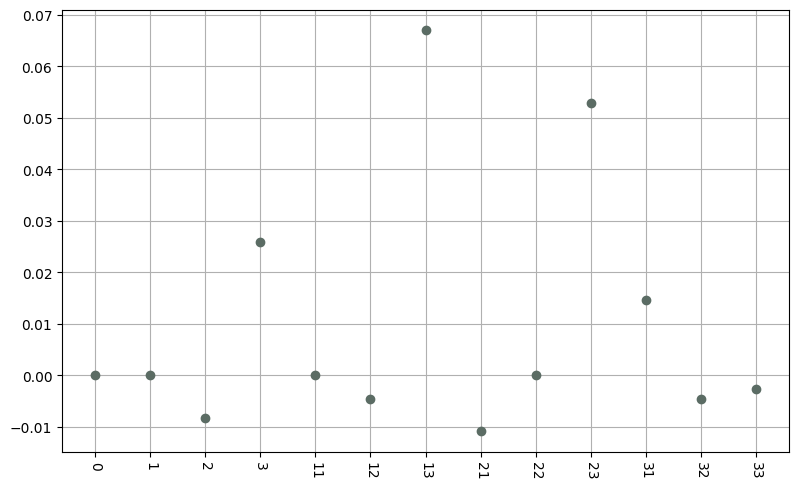

In [405]:
# 5. Fit on Train Data
# Note: y_train is already aligned with the output of sig.transform(X_train)
# pipe.fit(X_train, y_train)

# 6. Predict
y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

# 7. Compute Metrics
metrics = {
    "Train": {
        "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "R2": r2_score(y_train, y_pred_train)
    },
    "Test": {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2": r2_score(y_test, y_pred_test)
    }
}

for split, results in metrics.items():
    print(f"{split} Metrics: RMSE = {results['RMSE']:.4f}, R2 = {results['R2']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dates_grid_masked, y, label="VI")
ax.plot(dates_grid_masked, pipe.predict(X), "--", label="Predicted")
ax.vlines(x=test_start_date, ymin=0.95 * np.min(y), ymax=1.05 * np.max(y), color="k")
ax.legend(loc="upper left")
plt.show()
# fig.savefig("SPX-VIX-EFM-Signature.pdf", format="pdf", transparent=True, bbox_inches="tight")

vol_coef = ta.from_array(array=pipe["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)

## Global model

In [11]:
trunc = 2
dim = 3
lam = np.array([18, 12, 2])
kwargs = {}

X_list = []
X_train_list = []
X_test_list = []
y_list = []
y_train_list = []
y_test_list = []
dates_list = []
# Constructing a big dataset
for volatility_index_ticker in vi_underlying_dict.keys():
    stock_index_ticker = vi_underlying_dict[volatility_index_ticker]

    df_country = pd.DataFrame(index=df.index, data=df[[stock_index_ticker, volatility_index_ticker]])
    df_country = df_country.dropna(subset=[stock_index_ticker])

    index = df_country.index
    time_grid = np.array((index - index[0]).days / 365)
    time_grid_train_test_threshold = np.array((test_start_date - index[0]).days / 365)
    dates_grid = pd.to_datetime(pd.Series(index))

    underlying = df_country[stock_index_ticker]
    vol_index = df_country[volatility_index_ticker]

    burn_in = np.where(index >= train_start_date)[0][0]


    log_price = np.log(underlying)
    log_price_shifted = np.concatenate([log_price[0:1], log_price[:-1]])
    quadratic_variation = np.concatenate([[0], np.cumsum(np.diff(log_price)**2)])

    vi_shifted = np.concatenate([vol_index[0:1], vol_index[:-1]])
    integrated_vi = np.cumsum(vol_index)
    integrated_shifted_vi = np.cumsum(vi_shifted)

    path = np.vstack([
        time_grid,
        log_price / 10,
        quadratic_variation,
        # integrated_shifted_vi
    ]).T

    X = np.hstack([time_grid[:, None], path])
    y = np.array(vol_index[burn_in:])

    transformer = EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **kwargs)
    X = transformer.fit_transform(X, y)

    y_nan_mask = ~np.isnan(y)
    X = X[y_nan_mask]
    y = y[y_nan_mask]
    time_grid_masked = time_grid[burn_in:][y_nan_mask]
    dates_grid_masked = dates_grid[burn_in:][y_nan_mask]

    X_train, X_test = X[time_grid_masked < time_grid_train_test_threshold], X[time_grid_masked >= time_grid_train_test_threshold]  # X_test is full path to maintain EFM state
    y_train, y_test = y[time_grid_masked < time_grid_train_test_threshold], y[time_grid_masked >= time_grid_train_test_threshold]

    X_list.append(X)
    y_list.append(y)
    X_train_list.append(X_train)
    y_train_list.append(y_train)
    X_test_list.append(X_test)
    y_test_list.append(y_test)

    dates_list.append(dates_grid_masked)

Global metrics
Train Metrics: RMSE = 0.0250, R2 = 0.9149
Test Metrics: RMSE = 0.0351, R2 = 0.7948


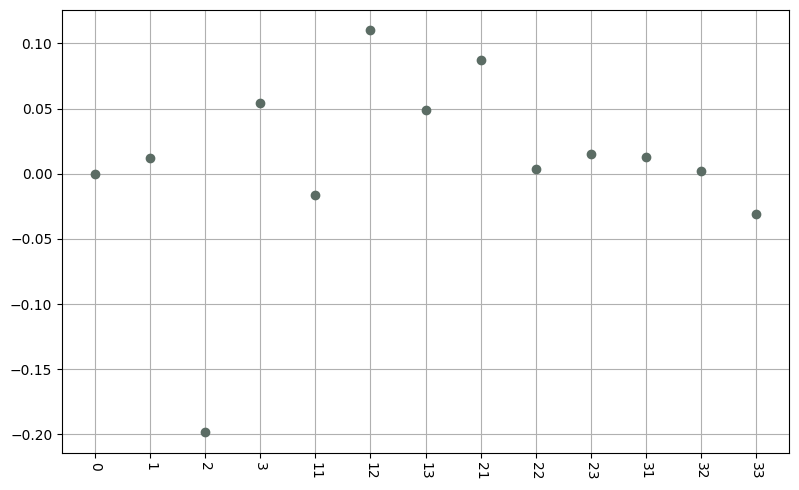

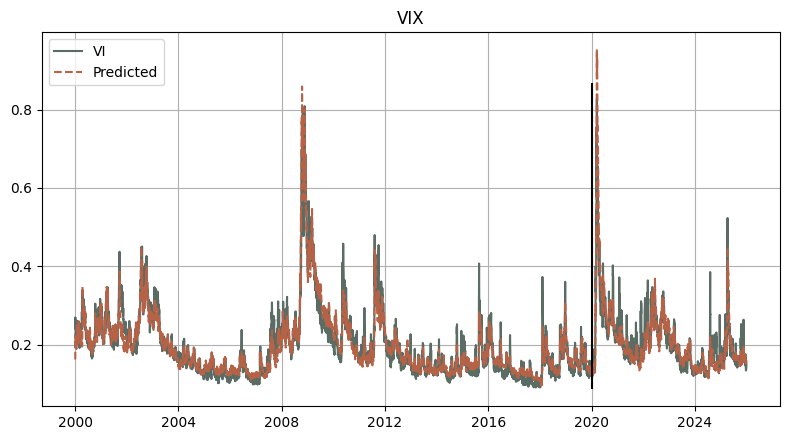

Train Metrics: RMSE = 0.0233, R2 = 0.9242
Test Metrics: RMSE = 0.0336, R2 = 0.8186


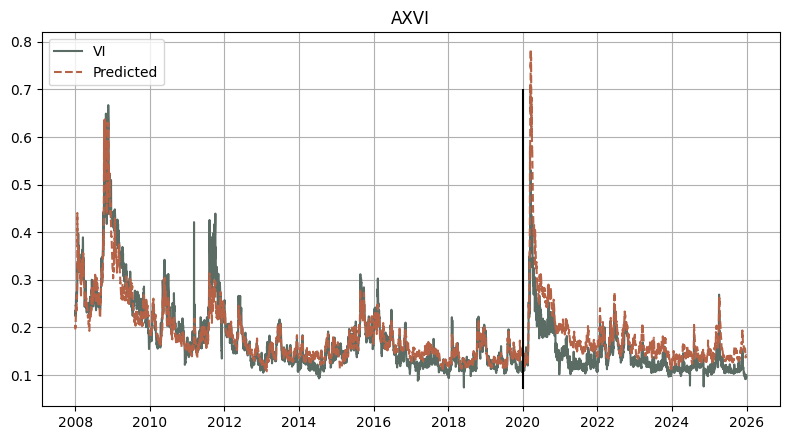

Train Metrics: RMSE = 0.0260, R2 = 0.9010
Test Metrics: RMSE = 0.0479, R2 = 0.0544


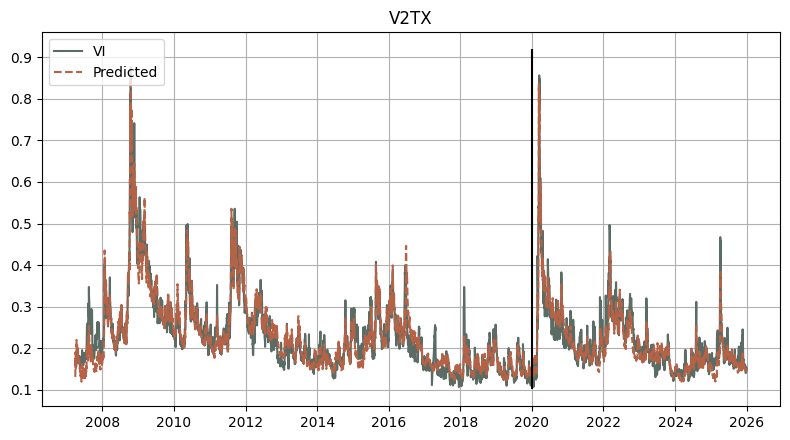

Train Metrics: RMSE = 0.0278, R2 = 0.9064
Test Metrics: RMSE = 0.0254, R2 = 0.8977


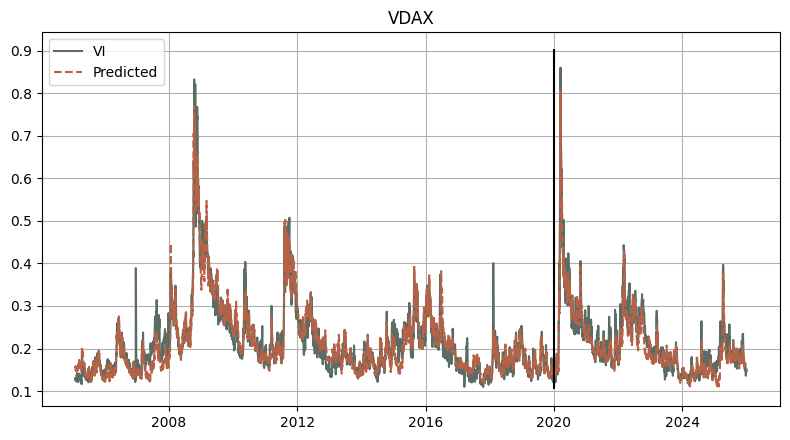

Train Metrics: RMSE = 0.0248, R2 = 0.9111
Test Metrics: RMSE = 0.0238, R2 = 0.9151


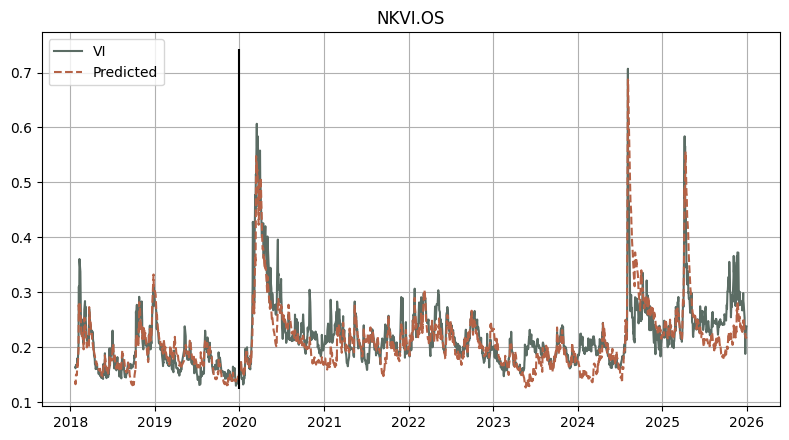

Train Metrics: RMSE = 0.0169, R2 = 0.8002
Test Metrics: RMSE = 0.0393, R2 = 0.5868


In [12]:
X_global = np.vstack(X_list)
y_global = np.concatenate(y_list)

X_global_train = np.vstack(X_train_list)
y_global_train = np.concatenate(y_train_list)

X_global_test = np.vstack(X_test_list)
y_global_test = np.concatenate(y_test_list)

pipe_global = Pipeline([
    # ('sig', EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **kwargs)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=0.1))
])

pipe_global.fit(X_global_train, y_global_train)
# pipe_global.fit(X_global, y_global)

y_pred_test = pipe_global.predict(X_global_test)
y_pred_train = pipe_global.predict(X_global_train)
metrics = {
        "Train": {
            "RMSE": np.sqrt(mean_squared_error(y_global_train, y_pred_train)),
            "R2": r2_score(y_global_train, y_pred_train)
        },
        "Test": {
            "RMSE": np.sqrt(mean_squared_error(y_global_test, y_pred_test)),
            "R2": r2_score(y_global_test, y_pred_test)
        }
    }
print("Global metrics")
for split, results in metrics.items():
    print(f"{split} Metrics: RMSE = {results['RMSE']:.4f}, R2 = {results['R2']:.4f}")

vol_coef = ta.from_array(array=pipe_global["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)

for X, y, dates, title, X_train, y_train, X_test, y_test  in zip(X_list, y_list, dates_list, vi_underlying_dict.keys(),
                                                                 X_train_list, y_train_list, X_test_list, y_test_list):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(dates, y, label="VI")
    ax.plot(dates, pipe_global.predict(X), "--", label="Predicted")
    ax.vlines(x=test_start_date, ymin=0.95 * np.min(y), ymax=1.05 * np.max(y), color="k")
    ax.legend(loc="upper left")
    ax.set_title(title)
    plt.show()

    y_pred_train = pipe_global.predict(X_train)
    y_pred_test = pipe_global.predict(X_test)

    metrics = {
        "Train": {
            "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
            "R2": r2_score(y_train, y_pred_train)
        },
        "Test": {
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
            "R2": r2_score(y_test, y_pred_test)
        }
    }
    for split, results in metrics.items():
        print(f"{split} Metrics: RMSE = {results['RMSE']:.4f}, R2 = {results['R2']:.4f}")

### Optimize the hyper-parameters

In [279]:
# 4. Learn the optimal lambdas
lam_dim = lam.size
lam_opt = optimize_lam_cv(X=X_train, y=y_train, model=pipe, burn_in=burn_in,
                          bounds=[(1, 20)] * lam_dim, init_guess=[5] * lam_dim,
                          optimizer="Powell")
pipe.set_params(sig__lam=lam_opt)

# 0.0010586263195815357
# 0.00087 BFGS 1.492e+01  2.000e+01  1.562e+00
# 0.000826 BFGS 2.000e+00  1.000e+01  2.923e+00

# # Grid search for the rolling signature
# param_grid = {
#     'sig__trunc': [2, 3, 4],
#     'sig__window_size': np.arange(1, 11),
#     'regressor__alpha': [0.1, 1.0, 10.0]
# }
# best_params, all_results = grid_search_cv_efm(X=X_train, y=y_train, model=pipe, param_grid=param_grid, burn_in=burn_in)
# pipe.set_params(**best_params)

ValueError: Invalid parameter 'sig' for estimator Pipeline(steps=[('scaler', StandardScaler()), ('regressor', Ridge())]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

### Grid Search optimization

In [135]:
import itertools

lambda_axis = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30])
# Generate all combinations for 3D
lambda_3d_grid = [np.array(p) for p in itertools.product(lambda_axis, repeat=3)]

# lambda_samples = random.sample(lambda_3d_grid, 100)

param_grid = {
    'sig__lam': lambda_3d_grid,
    'regressor__alpha': [0.1, 1.0, 10.0]
}

best_p, all_results = grid_search_cv_efm(
    X=X_train,
    y=y_train,
    model=pipe,
    param_grid=param_grid,
    burn_in=burn_in
)

print("\nBest Parameters Found:")
print(best_p)

/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 1, 1])} | Mean CV MSE: 0.004300


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 1, 2])} | Mean CV MSE: 0.013425
Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 1, 3])} | Mean CV MSE: 0.013794


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

...

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 3, 2])} | Mean CV MSE: 0.002378
Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 3, 3])} | Mean CV MSE: 0.002725


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

Params: {'regressor__alpha': 0.1, 'sig__lam': array([1, 3, 5])} | Mean CV MSE: 0.028421


/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
/Users/dimitri.sotnikov/Projets/Signature/signature/learning/hyperparameters_optimization.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]


KeyboardInterrupt: 